In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_rel, wilcoxon, mannwhitneyu

def read_data_to_df(path_to_results: str):
    dfs = []
    
    for cpus in os.listdir(path_to_results):
        for results_file in os.listdir(os.path.join(path_to_results, cpus)):
            method_name = results_file.split("_")[0]
            df = pd.read_csv(os.path.join(path_to_results, cpus, results_file))
            df["cpus"] = cpus
            df["method"] = method_name
            dfs.append(df)
    
    return pd.concat(dfs)

In [2]:
COLOR_NAIVE = "#a1273b"
COLOR_NUMPY = "#2323a1"
COLOR_NUMBA = "#13750f"
COLOR_GPU = "#fca503"

LINEWIDTH = 2
MARKERSIZE = 8
FONTSIZE = 12

METHOD_ORDER = ["naive", "numpy", "numba", "gpu"]


In [3]:
# df = read_data_to_df("./results")
df = pd.read_csv("results/merged.csv")

In [11]:
df_means = df[df["cpus"] == 8]
df_m = df_means.groupby(["size", "method"])["time_seconds"].mean().reset_index(name="mean_time_seconds")
df_sd = df_means.groupby(["size", "method"])["time_seconds"].std().reset_index(name="sd_time_seconds")
df_means = pd.merge(df_m, df_sd, how = "inner", on = ["size", "method"])
df_means.reset_index(drop=True)

,size,method,mean_time_seconds,sd_time_seconds
0,10,gpu,0.006586,2.040367e-02
1,10,naive,0.000930,3.347092e-06
2,10,numba,0.000015,1.503503e-06
3,10,numpy,0.000002,5.636318e-08
4,50,gpu,0.000144,1.003166e-05
5,50,naive,0.067716,2.040922e-02
6,50,numba,0.000028,9.033456e-07
7,50,numpy,0.000009,8.133711e-08
8,100,gpu,0.000153,5.736454e-06
9,100,naive,0.445710,1.602476e-03


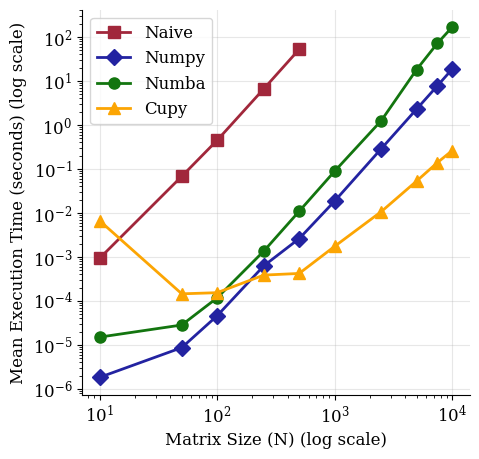

In [15]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.size"] = FONTSIZE

df1 = df[df["cpus"] == 8]
df1 = (
    df1.groupby(["method", "size"])["time_seconds"]
    .mean()
    .reset_index(name="mean_time_seconds")
)

plt.figure(figsize=(5, 5))
x = df1[df1["method"] == "gpu"]["size"]
plt.plot(
    df1[df1["method"] == "naive"]["size"],
    df1[df1["method"] == "naive"]["mean_time_seconds"],
    "s-",
    label="Naive",
    color=COLOR_NAIVE,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
)
plt.plot(
    x,
    df1[df1["method"] == "numpy"]["mean_time_seconds"],
    "D-",
    label="Numpy",
    color=COLOR_NUMPY,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.plot(
    x,
    df1[df1["method"] == "numba"]["mean_time_seconds"],
    "o-",
    label="Numba",
    color=COLOR_NUMBA,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.plot(
    x,
    df1[df1["method"] == "gpu"]["mean_time_seconds"],
    "^-",
    label="Cupy",
    color=COLOR_GPU,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Matrix Size (N) (log scale)")
plt.ylabel("Mean Execution Time (seconds) (log scale)")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig("visualizations/plot1.pdf", format="pdf", bbox_inches="tight")

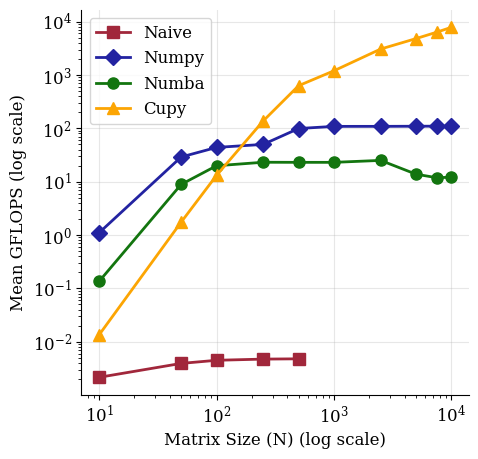

In [16]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.size"] = FONTSIZE

df2 = df[df["cpus"] == 8]
df2 = (
    df2.groupby(["method", "size"])["gflops"]
    .mean()
    .reset_index(name="mean_gflops")
)

plt.figure(figsize=(5, 5))
x = df2[df2["method"] == "gpu"]["size"]
plt.plot(
    df2[df2["method"] == "naive"]["size"],
    df2[df2["method"] == "naive"]["mean_gflops"],
    "s-",
    label="Naive",
    color=COLOR_NAIVE,
    linewidth=LINEWIDTH,
    ms=MARKERSIZE,
)
plt.plot(
    x,
    df2[df2["method"] == "numpy"]["mean_gflops"],
    "D-",
    label="Numpy",
    color=COLOR_NUMPY,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.plot(
    x,
    df2[df2["method"] == "numba"]["mean_gflops"],
    "o-",
    label="Numba",
    color=COLOR_NUMBA,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.plot(
    x,
    df2[df2["method"] == "gpu"]["mean_gflops"],
    "^-",
    label="Cupy",
    color=COLOR_GPU,
    linewidth=LINEWIDTH,
    ms = MARKERSIZE
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Matrix Size (N) (log scale)")
plt.ylabel("Mean GFLOPS (log scale)")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig("visualizations/plot2.pdf", format="pdf", bbox_inches="tight")

<Figure size 2000x500 with 0 Axes>

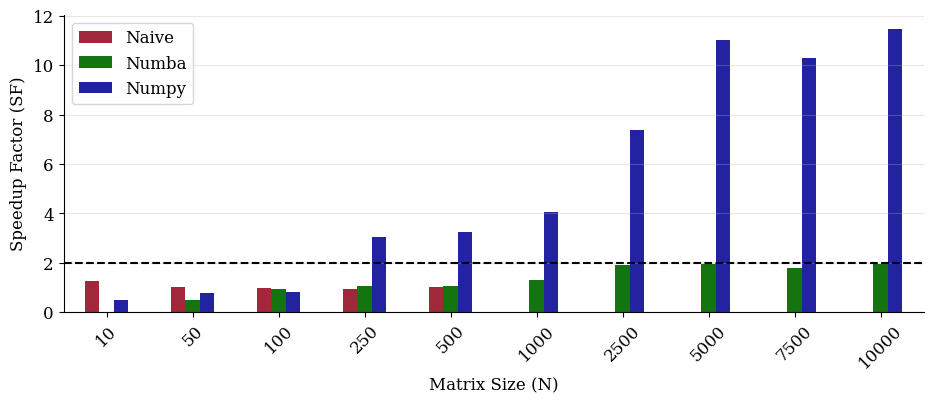

In [17]:
df3 = df[df["cpus"] == 8]
df4 = df[df["cpus"] == 16]
df3 = df3.groupby(["method", "size"])["time_seconds"].mean().reset_index(name="mean_time_seconds")
df4 = df4.groupby(["method", "size"])["time_seconds"].mean().reset_index(name="mean_time_seconds")

df5 = pd.merge(df3, df4, how="inner", on=["method", "size"], suffixes=("_8", "_16"))
df5["sf"] = df5["mean_time_seconds_8"] / df5["mean_time_seconds_16"]

df5['method'] = df5['method'].str.capitalize()
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.size"] = FONTSIZE

plt.figure(figsize=(20,5))
df5.pivot(index='size', columns='method', values='sf').plot(kind='bar', color=[COLOR_NAIVE, COLOR_NUMBA, COLOR_NUMPY, COLOR_GPU])
plt.xlabel('Matrix Size (N)')
plt.ylabel('Speedup Factor (SF)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=2, linestyle='--', color='black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gcf().set_size_inches(10, 4)
plt.savefig("visualizations/plot3.pdf", format="pdf", bbox_inches="tight")


In [11]:
for size in df["size"].unique():
    for method in ["numpy", "numba"]:
        x = df[(df["size"] == size) & (df["method"] == method) & (df["cpus"] == 8)]["time_seconds"]
        y = df[(df["size"] == size) & (df["method"] == method) & (df["cpus"] == 16)]["time_seconds"]
        diff = x.reset_index(drop=True) - y.reset_index(drop=True)
        _, p_val = mannwhitneyu(x, y, alternative="two-sided")
        res = p_val < 0.05
        print(f"{method} {size} Result: {res} {p_val}")
        

numpy 10 Result: True 0.00018267179110955002
numba 10 Result: True 0.00018267179110955002
numpy 50 Result: True 0.00018267179110955002
numba 50 Result: True 0.00018267179110955002
numpy 100 Result: True 0.00018267179110955002
numba 100 Result: True 0.0028272720911168077
numpy 250 Result: True 0.00018267179110955002
numba 250 Result: True 0.0028272720911168077
numpy 500 Result: True 0.00018267179110955002
numba 500 Result: True 0.0002461281279052297
numpy 1000 Result: True 0.00018267179110955002
numba 1000 Result: True 0.021133928129161098
numpy 2500 Result: True 0.00018267179110955002
numba 2500 Result: True 0.00018267179110955002
numpy 5000 Result: True 0.00018267179110955002
numba 5000 Result: True 0.00018267179110955002
numpy 7500 Result: True 0.00018267179110955002
numba 7500 Result: True 0.00017761066068896377
numpy 10000 Result: True 0.00018267179110955002
numba 10000 Result: True 0.00017761066068896377
